In [24]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

N = 256
L = 2.*np.pi
grid_dims = (N, N)
phys_dims = (L, L)


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in power
  terms.append((xx/bb[0])**(-a[0]))
/home/m/Documents/science_codes/Kea/Kea/simulator/fbm.py:62: RuntimeWarning: invalid value encountered in multiply
  output = np.sqrt(output * C)


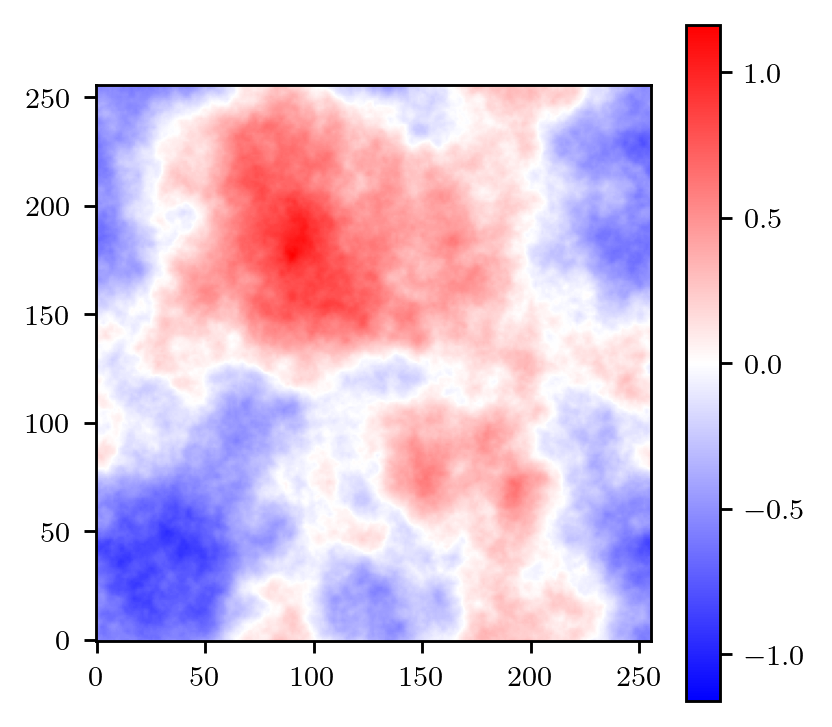

In [25]:
np.random.seed(1234)
x2 = fbm.create_fbm(grid_dims, phys_dims, (-11./3.,), (1.,))
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
im = ax.imshow(x2, origin='lower', cmap='bwr', vmin=-np.max(np.abs(x2)), vmax=np.max(np.abs(x2)))
fig.colorbar(im)

In [26]:
lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in x2.shape])
sf2 = strfn.process_lags(x2, x2, lv2, periodic=True, lenn=(2.*np.pi, 2.*np.pi), shape=tuple([2*n+1 for n in x2.shape]), orders=[2])[0]
#ssim_ks, ssim_feks, _ = spectra_base.calculate_integrated_spectrum((ssim_sf2,), method='strfn', spec_type='modal', int_kwargs=int_kwargs, lenn=L)
#ssim_i_sf = strfn_spectra.interpolate(ssim_ks, ssim_feks, ssim_k)
#lv = statfunc_base.get_all_lagvecs(x2.shape)
#strfn.process_lags(x2, x2, lv, (2.*np.pi, 2.*np.pi), (256, 256))

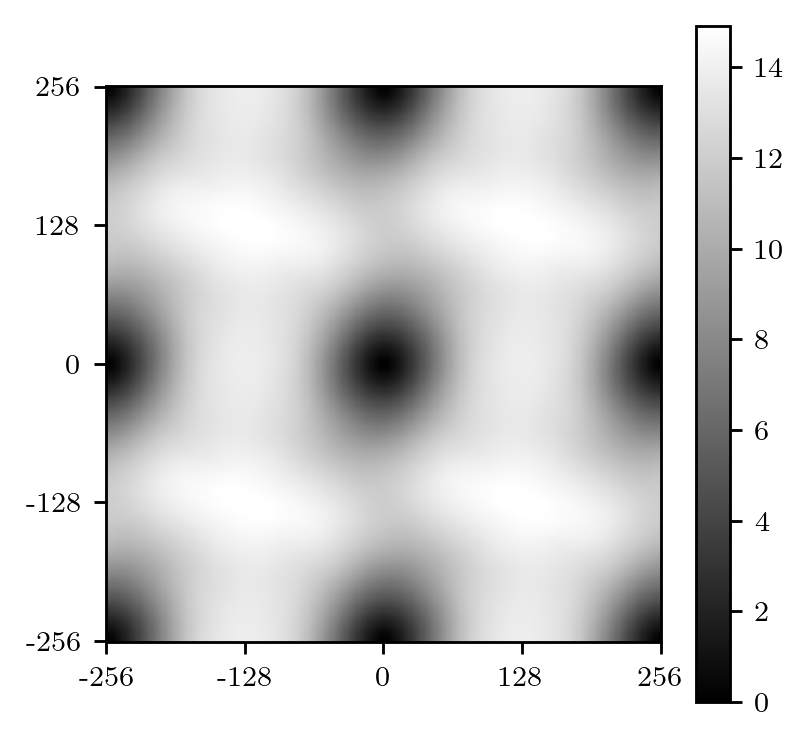

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
im = ax.imshow(sf2, origin='lower', cmap='gist_gray', interpolation='none')
ax.set_xticks([0, N//2, N, 3.*N//2, 2.*N], [-N, -N//2, 0, N//2, N])
ax.set_yticks([0, N//2, N, 3.*N//2, 2.*N], [-N, -N//2, 0, N//2, N])
fig.colorbar(im)

In [28]:
k, fek = strfn_spectra.omni_spectrum_2(sf2)

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[ 1.43607525 -3.57410366]


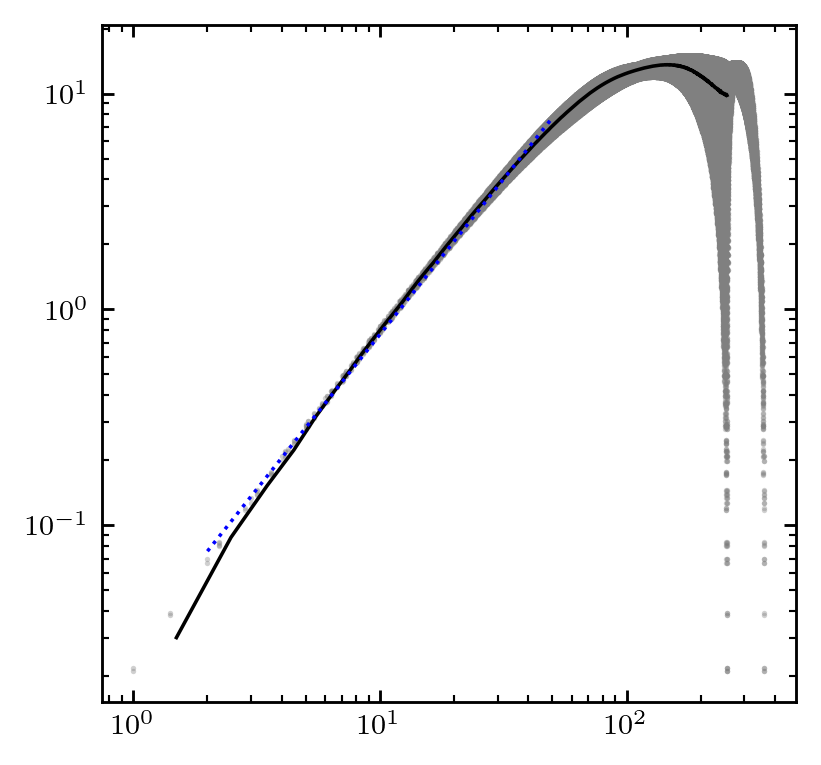

In [29]:
lvm = statfunc_base.get_lagvec_magnitude_array(sf2.shape)
l, sf, _ = statistics_base.bin_data(lvm, sf2, mean_func=np.nanmean, cut_excess=True, min_bin=1., ignore_nan=True)
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

ax.scatter(lvm, sf2, color='gray', marker='.', s=1., alpha=0.2)
ax.loglog(l, sf, linewidth=1., linestyle='-', color='black')

z, xx, p = fit_base.fit_powerlaw(l, sf, 2., 50.)
print(z)
ax.loglog(xx, p, color='blue', linewidth=1., linestyle=':')

#ax.set_ylim((1e-2, 1e2))

In [30]:
kp, fekp, _ = spectra_base.calculate_integrated_spectrum([x2,], spec_type='modal', lenn=(L, L))
ks, feks, _ = spectra_base.calculate_integrated_spectrum([sf2,], spec_type='modal', method='strfn', lenn=L)

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


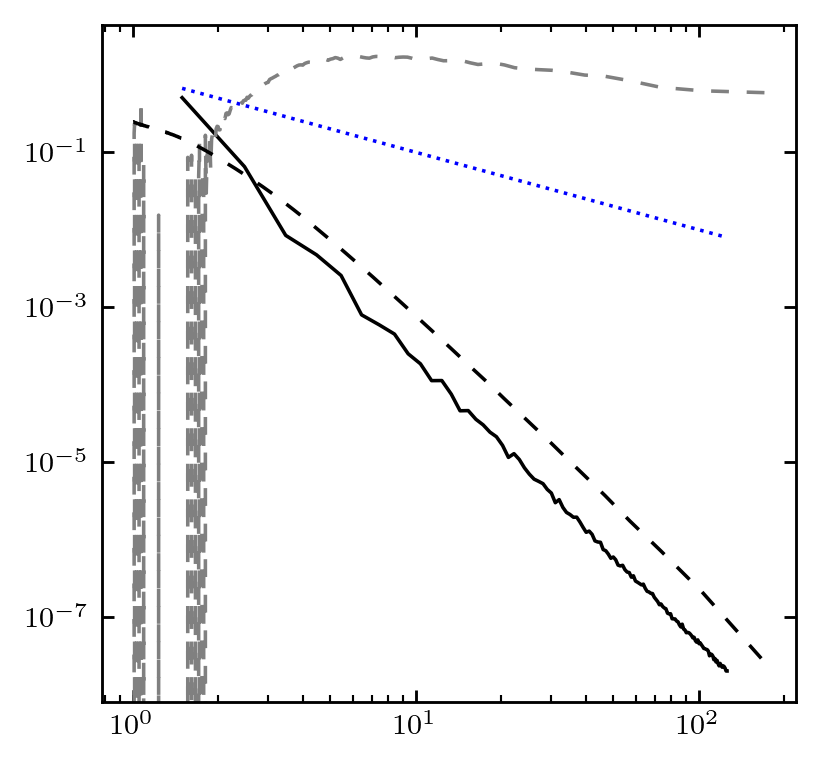

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

ax.loglog(kp, fekp, linewidth=1., linestyle='-', color='black')
ax.loglog(kp, kp**(-1.), linewidth=1., linestyle=':', color='blue')
ax.loglog(k, fek, linewidth=1., linestyle=(0, (5, 5)), color='gray')
ax.loglog(ks, feks, linewidth=1., linestyle=(0, (5, 5)), color='black')